In [2]:
import torch 
import torch.nn as nn
from torch.utils.data import DataLoader

import pandas as pd
import numpy as np
import seaborn as sns

In [3]:
live = pd.read_csv("../data/samples/trial/live_metrics.csv")
verbose = pd.read_csv("../data/samples/trial/verbose_statements.csv")
initial = pd.read_csv("../data/samples/trial/initial_statement.csv")

In [4]:
live = live.drop(['Unnamed: 0', "_id", "Category", "Collect", ], axis=1)
live = live.dropna()

In [5]:
live['Current Time'] = pd.to_datetime(live['Current Time'])
live['Current Time'] = pd.to_numeric(live['Current Time'])

In [6]:
response_time = verbose['total_duration'].tolist()
eval_rate = verbose['eval_rate'].tolist()
response_time = response_time[:-1]
reset_iters = live[live['Iteration'] == 1].index.tolist()
eval_rates = [np.float64(evals[:-9]) for evals in eval_rate]

In [7]:
live.corr()

,GPU Utilization (%),Power Draw (Watts),GPU Temp (°C),GPU Current Clock (MHz),Memory Current Clock (MHz),Memory Allocation Used (MB),Memory Utilization (%),Current Time,Time Delta,Iteration,GPU Clock Utilization,Memory Clock Utilization
GPU Utilization (%),1.000000,0.593940,0.850593,0.566516,NaN,0.558457,0.984606,0.229820,0.229794,0.193269,0.566516,NaN
Power Draw (Watts),0.593940,1.000000,0.632645,0.940428,NaN,0.926230,0.582237,0.134023,0.133995,0.169276,0.940428,NaN
GPU Temp (°C),0.850593,0.632645,1.000000,0.648092,NaN,0.638945,0.834220,0.447643,0.447632,0.070172,0.648092,NaN
GPU Current Clock (MHz),0.566516,0.940428,0.648092,1.000000,NaN,0.984983,0.561601,0.204384,0.204359,0.070822,1.000000,NaN
Memory Current Clock (MHz),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Memory Allocation Used (MB),0.558457,0.926230,0.638945,0.984983,NaN,1.000000,0.554592,0.202572,0.202557,0.068923,0.984983,NaN
Memory Utilization (%),0.984606,0.582237,0.834220,0.561601,NaN,0.554592,1.000000,0.265172,0.265147,0.119363,0.561601,NaN
Current Time,0.229820,0.134023,0.447643,0.204384,NaN,0.202572,0.265172,1.000000,0.999995,-0.493058,0.204384,NaN
Time Delta,0.229794,0.133995,0.447632,0.204359,NaN,0.202557,0.265147,0.999995,1.000000,-0.493056,0.204359,NaN
Iteration,0.193269,0.169276,0.070172,0.070822,NaN,0.068923,0.119363,-0.493058,-0.493056,1.000000,0.070822,NaN


In [8]:
live = live.drop(columns=['Memory Clock Utilization', 'Memory Current Clock (MHz)'])

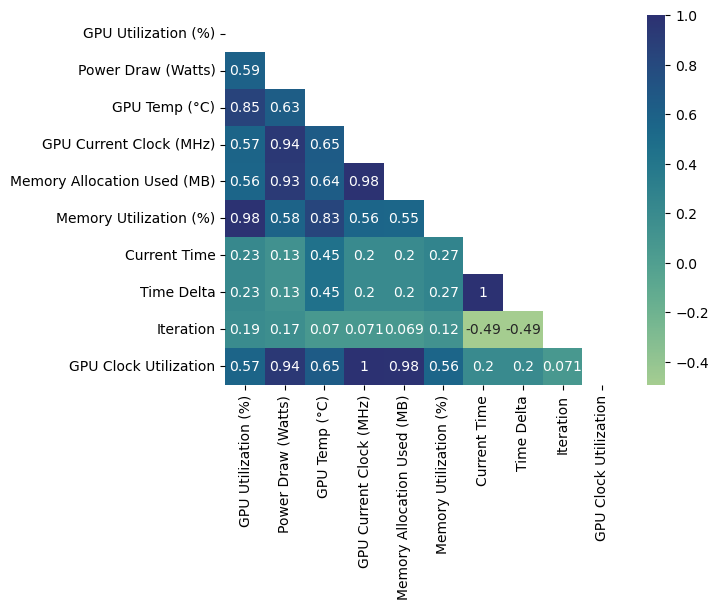

In [9]:
mask = np.triu(np.ones_like(live.corr(), dtype=bool))
heatmap = sns.heatmap(live.corr(), mask=mask, cmap='crest', annot=True)

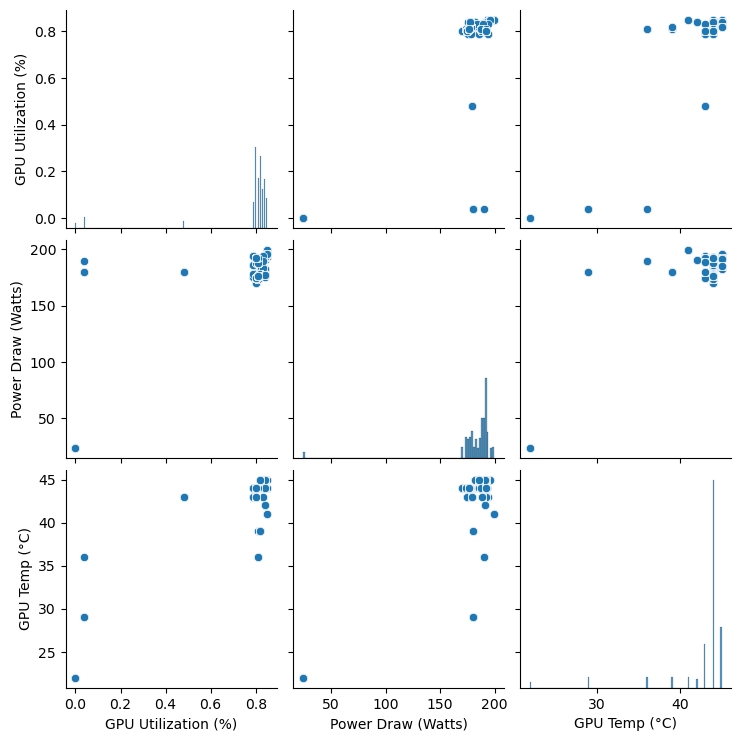

In [10]:
pair_plot = sns.pairplot(live.iloc[:, :3])

In [11]:
column_names = live.columns.tolist()
live_avg = dict(zip(column_names, [list(range(70))] * len(column_names)))
live_avg = pd.DataFrame(live_avg, dtype=np.float64)

In [12]:
for iter in range(1, len(reset_iters)):
    for column in live.columns:
        temp_list = live.iloc[reset_iters[iter-1]:reset_iters[iter],  column_names.index(column)].tolist()
        live_avg.iloc[iter-1, column_names.index(column)] = np.float64(np.average(temp_list))

In [13]:
live_avg = live_avg.iloc[:-1,:]

In [27]:
from sklearn.preprocessing import normalize, StandardScaler

live_avg_norm = normalize(live_avg)
ss = StandardScaler()
live_avg_scaled = ss.fit_transform(live_avg)

In [28]:
live_avg_scaled = pd.DataFrame(data=live_avg_scaled)
live_avg_scaled.columns = live_avg.columns


live_avg_norm = pd.DataFrame(data=live_avg_norm)
live_avg_norm.columns = live_avg_norm.columns

In [15]:
live_avg['Resonse Time'] = response_time
live_avg['Eval Rate'] = eval_rates[:-1]

In [29]:
live_avg.to_csv("../data/samples/live_avg.csv")
live_avg_scaled.to_csv("../data/samples/live_avg_scaled.csv")
live_avg_norm.to_csv("../data/samples/live_avg_norm.csv")